In [1]:
%matplotlib inline
import netCDF4 as nc  # CASE SENSITIVE! conda install -c conda-forge netcdf4
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colorbar import Colorbar
import matplotlib.patches as patches
from IPython.display import display, Image, clear_output

import time
from matplotlib import animation, rc
from IPython.display import HTML

rc("animation", html="jshtml")

# PyTorch
import torch
from torch.utils import data
import torch.nn as nn
from torch.nn.functional import mse_loss, l1_loss, cross_entropy
from torch import optim

cmap = plt.cm.RdBu

# Exercise

The research presented by Irrgang et al. 2020 uses an existing model of terrestrial water storage (TWS) in south-america to train a CNN to perform TWS estimations from (synthetic) satellite observations and altimetry.

The notebook ex5\_7\_TWS_from_gravity_and_altimetry implements a CNN similar in structure to the one presented by Irrgang et al.

After running the notebook your task is to:

1. Implement the loss function as described in Irrgang et al. (shown below) and choose a reasonable $\alpha$ value

$$
L(y_{lsdm}, y_{cnn},y_{alt})=\frac{\alpha}{N}\sum^N_{i=1}(y_{lsdm,i}-y_{cnn,i})^2 + \frac{1-\alpha}{M}\sum^M_{j=1}(y_{alt,j}-y_{cnn,j})^2
$$


2. Add more kernels and regularization to the network to get a model that doesn't overfit
    - Optional: Implement your own network structure



# Method from Irrgang et al. 2020

1. Forward simulation with a Land Surface Discharge Model (LSDM) to estimate Terrestrial water storage anomalies (TWSAs)
    - Monthly averaged data from 2003-2019
2. Spatial smoothing to simulate GRACE satellite observations
3. Spatial smoothing is taken as input to CNN with forward simulation as the training label
4. Further constraint is added by adding a loss term based on Surface Water Storage Anomalies (SWSAs) from altimetry


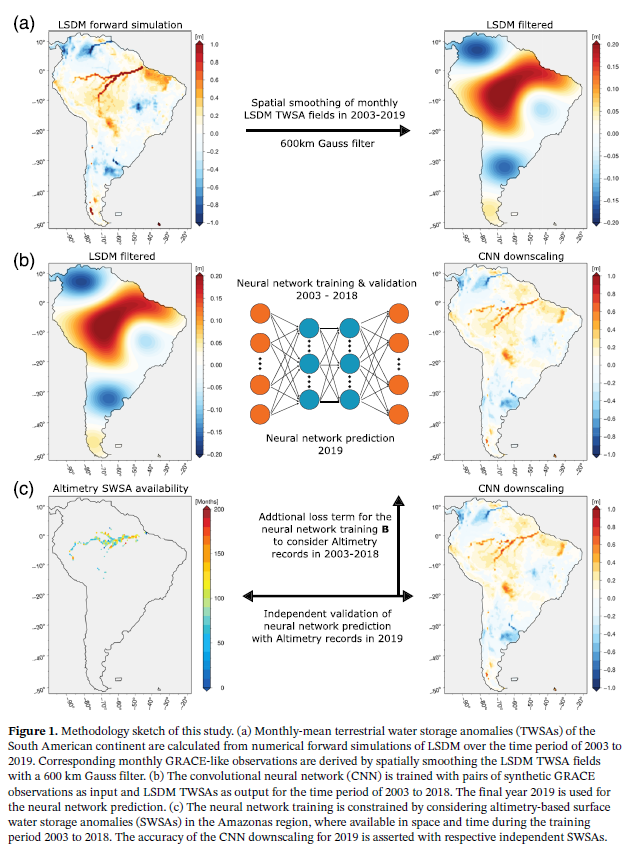

In [2]:
Image(filename="Irrgang_method.png")

# Load data

In [3]:
lsdm_tws_g600 = nc.Dataset(
    "lsdm_tws_anomalies_southamerica_2003_2019_gauss600.nc"
)  # Smoothed forward simulation (Input)
lsdm_tws = nc.Dataset(
    "lsdm_tws_anomalies_southamerica_2003_2019.nc"
)  # Forward simulation (Label)
alt = nc.Dataset(
    "altimetry_sws_anomalies_amazonas_2003_2019.nc"
)  # Altimetry (extra information)

# Time information extraction
stime = np.array(lsdm_tws_g600.variables["time"])
indices = [0, 4, 6]
tparts = []
for k in np.arange(0, len(stime)):
    tparts.append([str(stime[k])[i:j] for i, j in zip(indices, indices[1:])])
tparts = np.array(tparts, dtype=int)

C:\Users\jeppe\AppData\Local\Temp\ipykernel_47012\2681104674.py:12: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  stime = np.array(lsdm_tws_g600.variables["time"])


In [4]:
lsdm_tws  # View at netCDF4 file

<class 'netCDF4.Dataset'>
root group (NETCDF3_CLASSIC data model, file format NETCDF3):
    CDI: Climate Data Interface version 1.6.4 (http://code.zmaw.de/projects/cdi)
    Conventions: CF-1.4
    CDO: Climate Data Operators version 1.6.4 (http://code.zmaw.de/projects/cdo)
    creator_name: Christopher Irrgang
    creator_email: irrgang@gfz-potsdam.de
    institution: Helmholtz Centre Potsdam, German Research Centre For Geosciences (GFZ)
    paper_reference: Irrgang, C., Saynisch-Wagner, J., Dill, R., Boergens, E., & Thomas, M. (2020). Self-validating deep learning for recovering terrestrial water storage from gravity and altimetry measurements. Geophysical Research Letters, 47, e2020GL089258. https://doi.org/10.1029/2020GL089258
    dimensions(sizes): lon(101), lat(140), time(204)
    variables(dimensions): float64 lon(lon), float64 lat(lat), float64 time(time), float32 mass(time, lat, lon)
    groups: 

## Visualize data

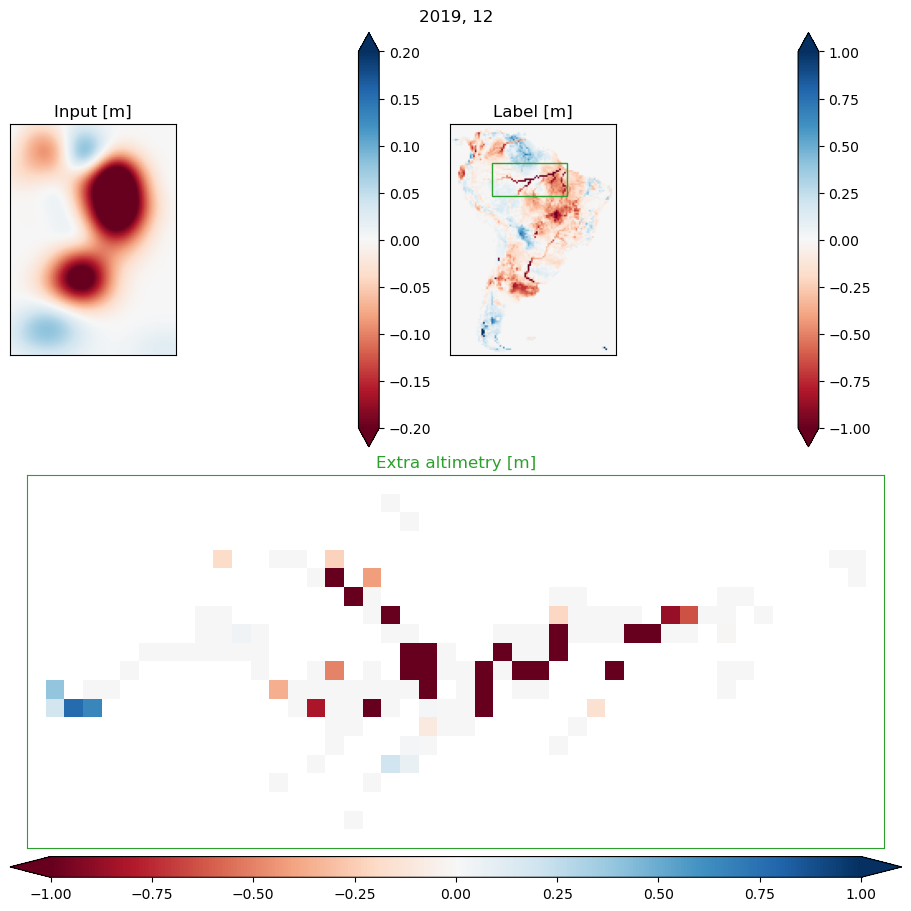

In [5]:
# # Data
# it = len(lsdm_tws_g600.variables["mass"])

# fig = plt.figure(
#     figsize=(9, 9), constrained_layout=True
# )  # Initiate figure with constrained layout
# tile_size_row = 2
# tile_size_column = 2

# # Generate ratio lists
# h_ratio = [1] * tile_size_row
# h_ratio[1] = 0.9
# h_ratio.append(0.05)
# w_ratio = [1] * tile_size_column
# w_ratio.append(0.1)

# gs = fig.add_gridspec(
#     tile_size_row + 1, tile_size_column + 1, height_ratios=h_ratio, width_ratios=w_ratio
# )

# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])
# ax3 = fig.add_subplot(gs[1, :])
# cbax3 = fig.add_subplot(gs[2, :])


# alt_c = "C2"
# for i in np.arange(0, it):
#     ax1.clear()
#     ax2.clear()
#     ax3.clear()

#     im1 = ax1.imshow(
#         lsdm_tws_g600.variables["mass"][i, :, :], cmap=cmap, vmin=-0.2, vmax=0.2
#     )
#     im2 = ax2.imshow(
#         lsdm_tws.variables["mass"][i, :, :], cmap=cmap, vmin=-1.0, vmax=1.0
#     )
#     im3 = ax3.imshow(
#         alt.variables["mass"][i, 23:43, 25:71], cmap=cmap, vmin=-1.0, vmax=1.0
#     )
#     ax1.set_title("Input [m]")
#     ax2.set_title("Label [m]")
#     ax3.set_title("Extra altimetry [m]", color=alt_c)

#     # cbar
#     if i == 0:
#         cb1 = fig.colorbar(mappable=im1, ax=ax1, orientation="vertical", extend="both")
#         cb2 = fig.colorbar(mappable=im2, ax=ax2, orientation="vertical", extend="both")
#         cb3 = Colorbar(mappable=im3, ax=cbax3, orientation="horizontal", extend="both")

#         # Create a Rectangle patch
#         rect = patches.Rectangle(
#             (25, 23), 46, 20, linewidth=1, edgecolor=alt_c, facecolor="none"
#         )

#     # Add the patch to the Axes
#     ax2.add_patch(rect)

#     # Time
#     plt.suptitle("{}, {}".format(tparts[i][0], tparts[i][1]))
#     # Finalize plots
#     ax1.axes.xaxis.set_visible(False)
#     ax1.axes.yaxis.set_visible(False)
#     ax2.axes.xaxis.set_visible(False)
#     ax2.axes.yaxis.set_visible(False)
#     ax3.axes.xaxis.set_visible(False)
#     ax3.axes.yaxis.set_visible(False)
#     for sps in ax3.spines:
#         ax3.spines[sps].set_color(alt_c)

#     display(fig)
#     clear_output(wait=True)
#     # Pause between each iteration
#     # time.sleep(0.0)


# Dataloader

In [6]:
# Define data in pytorch tensors
inp = torch.from_numpy(
    np.array(np.expand_dims(lsdm_tws_g600.variables["mass"][:, :, :], 0))
).float()  # Input
obs = torch.from_numpy(np.array(lsdm_tws.variables["mass"][:, :, :])).float()  # Label
inp_extra = torch.from_numpy(
    np.array(alt.variables["mass"][:, :, :])
).float()  # Extra loss information

In [7]:
# np.expand_dims as Pytorch leaves first dimension for possible channels, e.g. RGB
inp.shape

torch.Size([1, 204, 140, 101])

In [8]:
# Design dataloader
class Dataset(data.Dataset):
    "Characterizes a dataset for PyTorch"

    def __init__(self, list_IDs, labels, inp, inp_extra, tparts):
        "Initialization"
        self.labels = labels
        self.list_IDs = list_IDs
        self.inp = inp
        self.inp_extra = inp_extra
        self.tparts = tparts

    def __len__(self):
        "Denotes the total number of samples"
        return len(self.list_IDs)

    def __getitem__(self, index):
        "Generates one sample of data"
        # Select sample
        ID = self.list_IDs[index]

        # Load data and get label
        x = self.inp[:, ID, :, :]
        x_extra = self.inp_extra[ID, :, :]
        y = self.labels[ID]
        time = self.tparts[ID]

        return x, y, x_extra, time

In [9]:
# Partition data using the dataloader
N_t = 204
split_frac = 0.9
batch_size = 3

# data ID
labels_ID = np.arange(0, len(obs))
labels_tuple = zip(labels_ID, obs)

# Partition IDs
idx_split_data = int(split_frac * N_t)
partition = {
    "train": labels_ID[:idx_split_data],
    "validation": labels_ID[idx_split_data:],
}  # IDs
labels = {ID: label for (ID, label) in labels_tuple}  # Labels

# Parameters
DL_params = {"batch_size": batch_size, "shuffle": False}

# Generators
training_set = Dataset(partition["train"], labels, inp, inp_extra, tparts)
training_generator = data.DataLoader(training_set, **DL_params)

validation_set = Dataset(partition["validation"], labels, inp, inp_extra, tparts)
validation_generator = data.DataLoader(validation_set, **DL_params)

In [10]:
print("Validation set: \n", tparts[idx_split_data:], end=" ")

Validation set: 
 [[2018    4]
 [2018    5]
 [2018    6]
 [2018    7]
 [2018    8]
 [2018    9]
 [2018   10]
 [2018   11]
 [2018   12]
 [2019    1]
 [2019    2]
 [2019    3]
 [2019    4]
 [2019    5]
 [2019    6]
 [2019    7]
 [2019    8]
 [2019    9]
 [2019   10]
 [2019   11]
 [2019   12]] 

# Simple CNN

### Glorot initialization

http://proceedings.mlr.press/v9/glorot10a/glorot10a.pdf?hc_location=ufi 
Equation (16) where n is layer size. In pytorch the layer size is called fan_in and fan_out for the layer below and above repsectively.

Pytorch docs: https://pytorch.org/docs/stable/nn.init.html

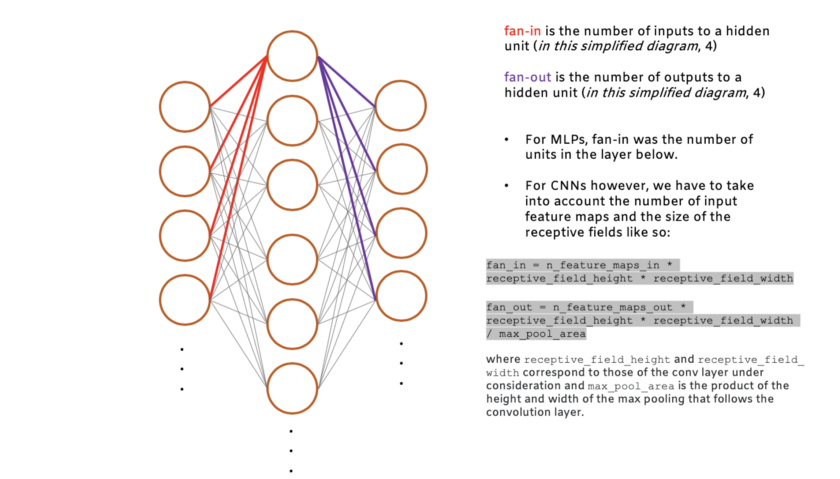

In [11]:
Image(filename="faninout.png")

In [12]:
class simpleCN(nn.Module):
    def __init__(self, layer_1, layer_2, layer_3, layer_4):
        super(simpleCN, self).__init__()

        # Store the input network
        self.layer_1 = layer_1
        self.layer_2 = layer_2
        self.layer_3 = layer_3
        self.layer_4 = layer_4

        # Initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                print(m, "initialized with Glorot and zero bias")
                m.weight = nn.init.xavier_uniform_(m.weight)
                m.bias.data.zero_()
            elif isinstance(m, nn.Linear):
                print(m, "initialized with Glorot and zero bias")
                m.weight = nn.init.xavier_uniform_(m.weight)
                m.bias.data.zero_()
            elif isinstance(m, nn.BatchNorm2d):
                print(m, "initialized with ones and zero bias")
                m.weight.data.fill_(1)
                m.bias.data.zero_()

    def forward(self, x):
        outputs = {}

        # Forward propagate input through the network
        out = self.layer_1(x)
        out = self.layer_2(out)
        out = self.layer_3(out)
        out = out.reshape(
            out.size(0), -1
        )  # Flatten output to [batch_size, linear layer 1 units]
        y = self.layer_4(out).reshape(-1, 140, 101)

        return y

### Calculating parameter sizes throughout network

In [13]:
def dim_out(wh_in, f, p, s):
    wh_out = (wh_in - f + 2 * p) / s + 1
    return wh_out


# Input image to first convolutional layer
h_in = 140
w_in = 101
print("Input")
print("h_in:\t\t", h_in)
print("w_in:\t\t", w_in)
print("")


fh = 5
fw = 6
s = 1
p = 2

h_out = dim_out(h_in, fh, p, s)
w_out = dim_out(w_in, fw, p, s)
print("first conv")
print("f:{}, s:{}, p:{}".format((fh, fw), s, p))
print("h_out:\t\t", h_out)
print("w_out:\t\t", w_out)
print("")

# first maxpool layer
fh = 7
fw = 5
sh = 7
sw = 5
ph = 0
pw = 0

h_out = dim_out(h_out, fh, ph, sh)
w_out = dim_out(w_out, fw, pw, sw)
print("first maxpool")
print("f:{}, s:{}, p:{}".format((fh, fw), (sh, sw), (ph, pw)))
print("h_out:\t\t", h_out)
print("w_out:\t\t", w_out)
print("")

# Input image to second convolutional layer
fh = 7
fw = 7
s = 1
p = 0

h_out = dim_out(h_out, fh, p, s)
w_out = dim_out(w_out, fw, p, s)

print("second conv")
print("f:{}, s:{}, p:{}".format((fh, fw), s, p))
print("h_out:\t\t", h_out)
print("w_out:\t\t", w_out)
print("")

# second maxpool layer
fh = 2
fw = 2
s = 2
p = 0

h_out = dim_out(h_out, fh, p, s)
w_out = dim_out(w_out, fw, p, s)
print("second maxpool")
print("f:{}, s:{}, p:{}".format((fh, fw), s, p))
print("h_out:\t\t", h_out)
print("w_out:\t\t", w_out)
print("")

# Input image to third convolutional layer
f = 3
s = 2
p = 0

w_out = dim_out(w_out, f, p, s)
h_out = dim_out(h_out, f, p, s)
print("third conv")
print("f:{}, s:{}, p:{}".format(f, s, p))
print("h_out:\t\t", h_out)
print("w_out:\t\t", w_out)
print("")

Input
h_in:		 140
w_in:		 101

first conv
f:(5, 6), s:1, p:2
h_out:		 140.0
w_out:		 100.0

first maxpool
f:(7, 5), s:(7, 5), p:(0, 0)
h_out:		 20.0
w_out:		 20.0

second conv
f:(7, 7), s:1, p:0
h_out:		 14.0
w_out:		 14.0

second maxpool
f:(2, 2), s:2, p:0
h_out:		 7.0
w_out:		 7.0

third conv
f:3, s:2, p:0
h_out:		 3.0
w_out:		 3.0



### Visualization
#### From input channels through kernels to output channels

https://cs231n.github.io/convolutional-networks/#conv

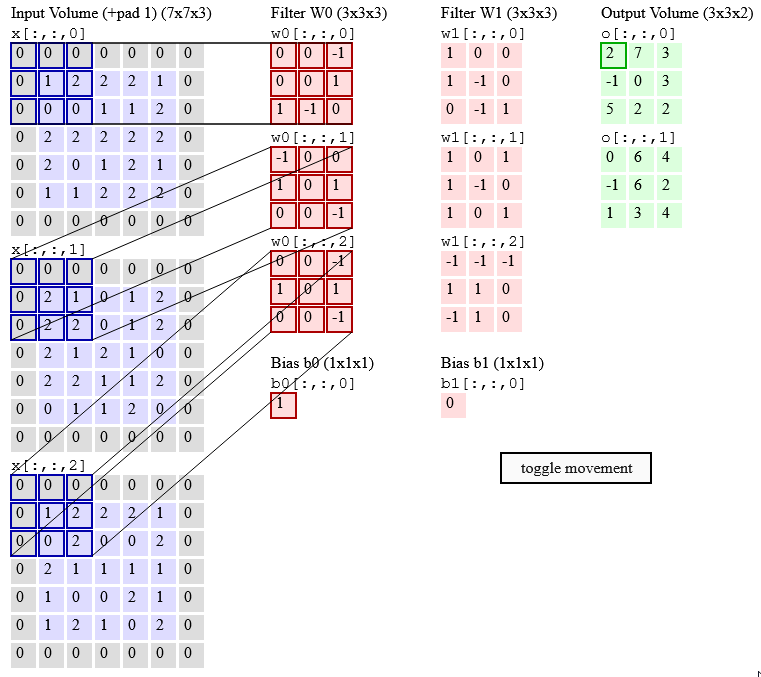

In [14]:
Image(filename="conv_channels_visualized.gif")

In [84]:
# TUTORIAL CONV NETWORK

K1 = 6
K2 = 12
K3 = 6
layer_1 = nn.Sequential(
    nn.Conv2d(1, K1, kernel_size=(5, 6), stride=1, padding=2),
    nn.Tanh(),
    nn.MaxPool2d(kernel_size=(7, 5), stride=(7, 5), padding=0),
)

layer_2 = nn.Sequential(
    nn.Conv2d(K1, K2, kernel_size=7, stride=1, padding=0),
    nn.Tanh(),
    nn.MaxPool2d(kernel_size=2, stride=2, padding=0),
    nn.Dropout(p=0.25),
)

layer_3 = nn.Sequential(
    nn.Conv2d(K2, K3, kernel_size=3, stride=2, padding=0),
    nn.Tanh(),
    nn.Dropout(p=0.50),
)


layer_4 = nn.Sequential(
    nn.Linear(3 * 3 * K3, 140 * 101),
)

net = simpleCN(layer_1, layer_2, layer_3, layer_4)

# Net size
net_N_param = sum([p.numel() for p in net.parameters()])
print("\nTrainable parameters: ", net_N_param)

# Transfer model to GPU if available
cuda_available = torch.cuda.is_available()
cuda_available = False  # Force CPU
if cuda_available:
    device = torch.device("cuda:0" if cuda_available else "cpu")
    print("Transferring net to single available GPU:", device)

    net = net.to(device)

print("\nNetwork structure")
print(net)

Conv2d(1, 6, kernel_size=(5, 6), stride=(1, 1), padding=(2, 2)) initialized with Glorot and zero bias
Conv2d(6, 12, kernel_size=(7, 7), stride=(1, 1)) initialized with Glorot and zero bias
Conv2d(12, 6, kernel_size=(3, 3), stride=(2, 2)) initialized with Glorot and zero bias
Linear(in_features=54, out_features=14140, bias=True) initialized with Glorot and zero bias

Trainable parameters:  782080

Network structure
simpleCN(
  (layer_1): Sequential(
    (0): Conv2d(1, 6, kernel_size=(5, 6), stride=(1, 1), padding=(2, 2))
    (1): Tanh()
    (2): MaxPool2d(kernel_size=(7, 5), stride=(7, 5), padding=0, dilation=1, ceil_mode=False)
  )
  (layer_2): Sequential(
    (0): Conv2d(6, 12, kernel_size=(7, 7), stride=(1, 1))
    (1): Tanh()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Dropout(p=0.25, inplace=False)
  )
  (layer_3): Sequential(
    (0): Conv2d(12, 6, kernel_size=(3, 3), stride=(2, 2))
    (1): Tanh()
    (2): Dropout(p=0.5, inplace=Fa

In [85]:
# Exercise 5_7_1, implement L = alpha*mse(y_out, y_label) + (1-alpha)*mse(y_out, y_extra)
def error_func(y_out, y_extra, y_label, alpha):

    # The altimetry data has a mask with the value 1e+32 at pixels without measurements
    i_extra = y_extra.lt(1e32)  # Indices of pixels containing altimetry data

    loss_lsdm = alpha * mse_loss(y_out, y_label, reduction="mean")
    loss_alt = (1 - alpha) * mse_loss(
        y_out[i_extra], y_extra[i_extra], reduction="mean"
    )
    L = loss_lsdm + loss_alt

    return L

In [86]:
x_valid, y_valid, x_ext_valid, _ = next(iter(validation_generator))
print(x_valid.shape)
print(y_valid.shape)
print(x_ext_valid.shape)

torch.Size([3, 1, 140, 101])
torch.Size([3, 140, 101])
torch.Size([3, 140, 101])


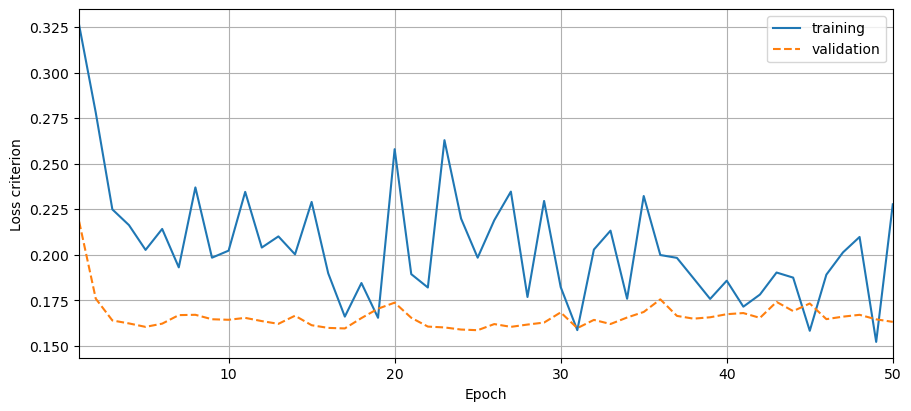

In [87]:
# optimizer = optim.SGD(net.parameters(), lr=0.1, weight_decay = 0.01)
optimizer = optim.Adam(net.parameters(), lr=0.001, weight_decay=0.0)

N_epochs = 50
alpha = 0.25

fig = plt.figure(
    figsize=(9, 4), constrained_layout=True
)  # Initiate figure with constrained layout
gs = fig.add_gridspec(1, 1)  # Add 1x2 grid
ax1 = fig.add_subplot(gs[0, 0])

E_train_collect, E_valid_collect = [], []

# Iterate over epochs
for epoch in np.arange(1, N_epochs + 1):
    # print(epoch)
    net.train()  # Set network in "training mode"

    # Go through each batch in the training dataset using the loader
    for x_train, y_train, x_ext_train, _ in training_generator:
        if cuda_available:
            x_train = x_train.to(device)
            y_train = y_train.to(device)
            x_ext_train = x_ext_train.to(device)

        y_out_train = net(x_train)  # Forward propagate through the network

        L_train = error_func(y_out_train, x_ext_train, y_train, alpha)  # Estimate error

        optimizer.zero_grad()  # Reset gradients to zero
        L_train.backward()  # Back-propagate to get the gradients based on the estimated error
        optimizer.step()  # Update through the optimizer (e.g. stochastic gradient descent)

    # Evaluate, do not propagate gradients
    with torch.no_grad():
        net.eval()  # Set network in "evaluation mode"

        # Just load a single validation batch from the test loader
        x_valid, y_valid, x_ext_valid, _ = next(iter(validation_generator))

        if cuda_available:
            x_valid = x_valid.to(device)
            y_valid = y_valid.to(device)
            x_ext_valid = x_ext_valid.to(device)

        y_out_valid = net(x_valid)  # Forward propagate the validation set

        L_valid = error_func(
            y_out_valid, x_ext_valid, y_valid, alpha
        )  # Compute the validation error

    E_train_collect.append(L_train.sum().detach().cpu().numpy())
    E_valid_collect.append(L_valid.sum().detach().cpu().numpy())

    # Finalize plots
    ax1.clear()
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss criterion")
    ax1.set_xlim([1, N_epochs])
    ax1.grid()
    ax1.plot(
        np.arange(1, epoch + 1), E_train_collect, "-", color="C0", label="training"
    )
    ax1.plot(
        np.arange(1, epoch + 1), E_valid_collect, "--", color="C1", label="validation"
    )
    ax1.legend(loc="upper right")
    display(fig)
    clear_output(wait=True)

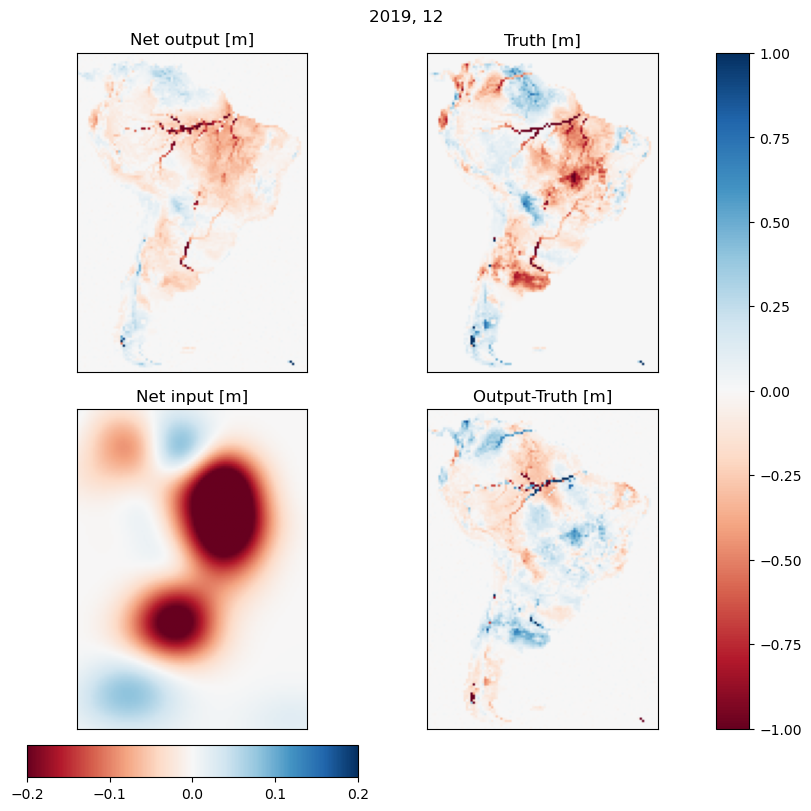

In [88]:
fig = plt.figure(
    figsize=(8, 8), constrained_layout=True
)  # Initiate figure with constrained layout

tile_size_row = 2
tile_size_column = 2

# Generate ratio lists
h_ratio = [1] * tile_size_row
h_ratio.append(0.1)
w_ratio = [1] * tile_size_column
w_ratio.append(0.1)

gs = fig.add_gridspec(
    tile_size_row + 1, tile_size_column + 1, height_ratios=h_ratio, width_ratios=w_ratio
)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])
ax3 = fig.add_subplot(gs[1, 0])
ax4 = fig.add_subplot(gs[1, 1])

cbax1 = fig.add_subplot(gs[0:2, 2])  # Set colorbar position
cbax3 = fig.add_subplot(gs[2, 0])  # Set colorbar position
with torch.no_grad():
    net.eval()  # Set network in "evaluation mode"

    x_plot, label_plot, _, _ = next(iter(validation_generator))

    if cuda_available:
        x_plot = x_plot.to(device)
        label_plot = label_plot.to(device)

    # x_plot, label_plot, _ = next(iter(training_generator))
    y_plot = net(x_plot)

    vmin1 = -1
    vmax1 = 1
    vmin2 = -0.2
    vmax2 = 0.2

    im1 = ax1.imshow(y_plot.cpu()[0, :, :], vmin=vmin1, vmax=vmax1, cmap=cmap)
    im2 = ax2.imshow(label_plot.cpu()[0, :, :], vmin=vmin1, vmax=vmax1, cmap=cmap)
    im3 = ax3.imshow(x_plot.cpu()[0, 0, :, :], vmin=vmin2, vmax=vmax2, cmap=cmap)
    # im4=ax4.imshow(abs(y_plot.cpu()[0,:,:]-label_plot.cpu()[0,:,:]), vmin = vmin1, vmax = vmax1, cmap=cmap)
    im4 = ax4.imshow(
        y_plot.cpu()[0, :, :] - label_plot.cpu()[0, :, :],
        vmin=vmin1,
        vmax=vmax1,
        cmap=cmap,
    )

    cb1 = Colorbar(mappable=im1, ax=cbax1, orientation="vertical")
    cb3 = Colorbar(mappable=im3, ax=cbax3, orientation="horizontal")

    ax1.set_title("Net output [m]")
    ax2.set_title("Truth [m]")
    ax3.set_title("Net input [m]")
    ax4.set_title("Output-Truth [m]")

    for x_valid, y_valid, x_ext_valid, tparts_valid in validation_generator:
        if cuda_available:
            x_valid = x_valid.to(device)
            y_valid = y_valid.to(device)
            x_ext_valid = x_ext_valid.to(device)

        y_out_valid = net(x_valid)  # Forward propagate the validation set

        # Initiation parameters
        for y_plot, label_plot, x_plot, t_plot in zip(
            y_out_valid, y_valid, x_valid, tparts_valid
        ):
            vmin1 = torch.min(label_plot)
            vmax1 = torch.max(label_plot)
            vmin2 = torch.min(x_plot[0, :, :])
            vmax2 = torch.max(x_plot[0, :, :])

            im1.set_data(y_plot.cpu())
            im2.set_data(label_plot.cpu())
            im3.set_data(x_plot.cpu()[0, :, :])
            # im4.set_data(abs(y_plot.cpu()-label_plot.cpu()))
            im4.set_data(y_plot.cpu() - label_plot.cpu())
            # Time
            plt.suptitle("{}, {}".format(t_plot[0], t_plot[1]))

            # Finalize plots
            ax1.axes.xaxis.set_visible(False)
            ax1.axes.yaxis.set_visible(False)
            ax2.axes.xaxis.set_visible(False)
            ax2.axes.yaxis.set_visible(False)
            ax3.axes.xaxis.set_visible(False)
            ax3.axes.yaxis.set_visible(False)
            ax4.axes.xaxis.set_visible(False)
            ax4.axes.yaxis.set_visible(False)
            display(fig)
            clear_output(wait=True)
            # Pause between each iteration
            time.sleep(0.5)

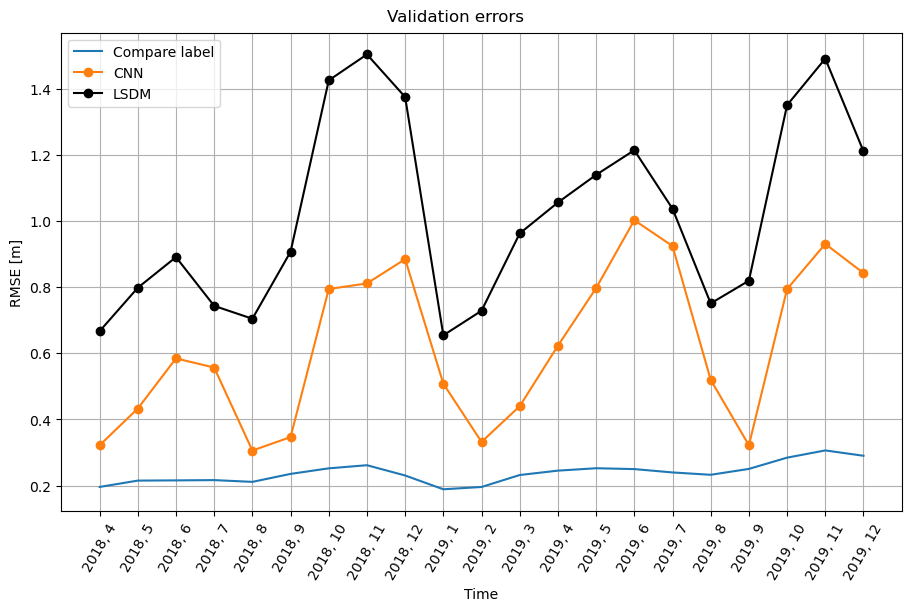

In [89]:
RMSES, RMSES_alt, RMSES_LSDM, tvals = [], [], [], []
with torch.no_grad():
    net.eval()  # Set network in "evaluation mode"

    for x_valid, y_valid, y_ext_valid, tparts_valid in validation_generator:
        if cuda_available:
            x_valid = x_valid.to(device)
            y_valid = y_valid.to(device)
            y_ext_valid = y_ext_valid.to(device)

        y_out_valid = net(x_valid)  # Forward propagate the validation set

        # Initiation parameters
        for y_plot, label_plot, x_plot, y_ext_plot, t_plot in zip(
            y_out_valid, y_valid, x_valid, y_ext_valid, tparts_valid
        ):
            idx_truth_mask = ~label_plot.eq(0.0)
            RMSES.append(
                torch.sqrt(mse_loss(y_plot[idx_truth_mask], label_plot[idx_truth_mask]))
            )

            idx_truth_mask_alt = y_ext_plot.lt(1e32)
            RMSES_alt.append(
                torch.sqrt(
                    mse_loss(y_plot[idx_truth_mask_alt], y_ext_plot[idx_truth_mask_alt])
                )
            )

            RMSES_LSDM.append(
                torch.sqrt(
                    mse_loss(
                        label_plot[idx_truth_mask_alt], y_ext_plot[idx_truth_mask_alt]
                    )
                )
            )
            # RMSES_LSDM.append(
            #     torch.sqrt(
            #         torch.mean(
            #             (
            #                 label_plot[idx_truth_mask_alt]
            #                 - y_ext_plot[idx_truth_mask_alt]
            #             )
            #             ** 2
            #         )
            #     )
            # )

            tvals.append("{}, {}".format(t_plot[0], t_plot[1]))

# Plot RMSE
fig = plt.figure(
    figsize=(9, 6), constrained_layout=True
)  # Initiate figure with constrained layout
gs = fig.add_gridspec(1, 1)
ax1 = fig.add_subplot(gs[0, 0])

# Finalize plots
ax1.clear()
ax1.set_xlabel("Time")
ax1.set_ylabel("RMSE [m]")
ax1.grid()
ax1.plot(np.arange(1, len(RMSES) + 1), RMSES, "-", color="C0", label="Compare label")
ax1.plot(np.arange(1, len(RMSES) + 1), RMSES_alt, "-o", color="C1", label="CNN")
ax1.plot(np.arange(1, len(RMSES) + 1), RMSES_LSDM, "-o", color="k", label="LSDM")
plt.xticks(np.arange(1, len(RMSES) + 1), tvals, rotation=60)
ax1.legend(loc="best")
plt.suptitle("Validation errors")
display(fig)
clear_output(wait=True)

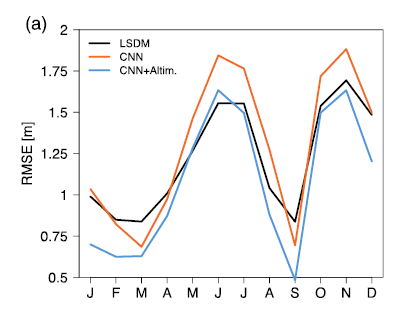

In [90]:
# Result from Irrgang et al. 2020, figure 4
Image(filename="Irrgang_alt_compare.png")

# Inspecting your trained network

In [93]:
x_valid, y_valid, x_ext_valid, _ = next(iter(validation_generator))
if cuda_available:
    x_valid = x_valid.to(device)
    y_valid = y_valid.to(device)
    x_ext_valid = x_ext_valid.to(device)

# Loop through modules
count = 0
for l in net.layer_1.modules():
    if count != 0:
        print(l)
    count += 1

Conv2d(1, 6, kernel_size=(5, 6), stride=(1, 1), padding=(2, 2))
Tanh()
MaxPool2d(kernel_size=(7, 5), stride=(7, 5), padding=0, dilation=1, ceil_mode=False)


IndexError: index 4 is out of bounds for axis 0 with size 4

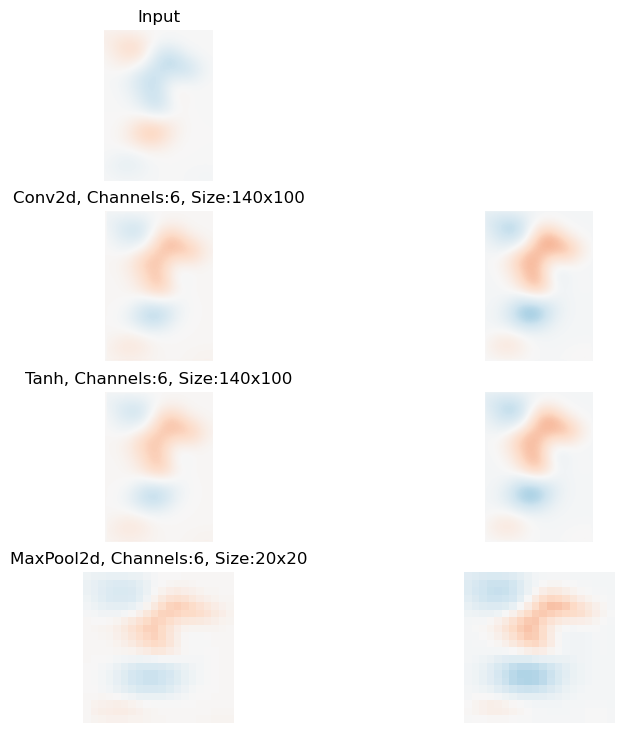

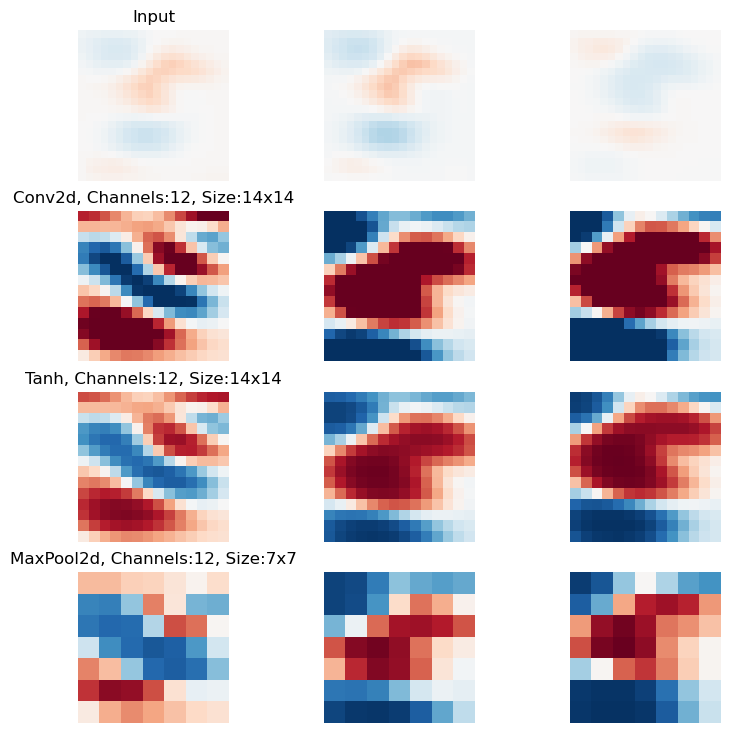

In [94]:
max_maps = 2
max_layers = 4

fig = plt.figure(figsize=(9, 9))  # Initiate figure with constrained layout
gs = fig.add_gridspec(max_layers, max_maps)

x_layer = x_valid

count = 0
for l in net.layer_1.modules():
    if count != 0:
        x_layer = l(x_layer.float())

        seq_type, _, _ = str(l).partition("(")
    else:
        seq_type = "Input"

    _, _, seq_size = str(x_layer.shape).partition("torch.Size([")
    seq_size, _, _ = seq_size.partition("])")
    seq_size = seq_size.rsplit(", ")

    N_ax = x_layer.shape[1]
    if N_ax > max_maps:
        N_ax = max_maps
    for i in np.arange(0, N_ax):
        ax = fig.add_subplot(gs[count, i])
        im = ax.imshow(
            x_layer[0, i, :, :].cpu().detach().numpy(), cmap=cmap, vmin=-1, vmax=1
        )
        ax.axis("off")
        if np.logical_and(count == 0, i == 0):
            ax.set_title(seq_type)
        elif i == 0:
            ax.set_title(
                seq_type
                + ", Channels:"
                + seq_size[1]
                + ", Size:"
                + seq_size[2]
                + "x"
                + seq_size[3]
            )

    count += 1

display(fig)
clear_output(wait=True)


max_maps = 3
max_layers = 4

fig = plt.figure(figsize=(9, 9))  # Initiate figure with constrained layout
gs = fig.add_gridspec(max_layers, max_maps)

count = 0
for l in net.layer_2.modules():
    if count != 0:
        x_layer = l(x_layer)

        seq_type, _, _ = str(l).partition("(")
    else:
        seq_type = "Input"

    _, _, seq_size = str(x_layer.shape).partition("torch.Size([")
    seq_size, _, _ = seq_size.partition("])")
    seq_size = seq_size.rsplit(", ")

    N_ax = x_layer.shape[1]
    if N_ax > max_maps:
        N_ax = max_maps
    for i in np.arange(0, N_ax):
        ax = fig.add_subplot(gs[count, i])
        im = ax.imshow(
            x_layer[0, i, :, :].cpu().detach().numpy(), cmap=cmap, vmin=-1, vmax=1
        )
        ax.axis("off")
        if np.logical_and(count == 0, i == 0):
            ax.set_title(seq_type)
        elif i == 0:
            ax.set_title(
                seq_type
                + ", Channels:"
                + seq_size[1]
                + ", Size:"
                + seq_size[2]
                + "x"
                + seq_size[3]
            )

    count += 1

display(fig)
clear_output(wait=True)


max_maps = 5
max_layers = 4

fig = plt.figure(figsize=(9, 9))  # Initiate figure with constrained layout
gs = fig.add_gridspec(max_layers, max_maps)

count = 0
for l in net.layer_3.modules():
    if count != 0:
        x_layer = l(x_layer)

        seq_type, _, _ = str(l).partition("(")
    else:
        seq_type = "Input"

    _, _, seq_size = str(x_layer.shape).partition("torch.Size([")
    seq_size, _, _ = seq_size.partition("])")
    seq_size = seq_size.rsplit(", ")

    N_ax = x_layer.shape[1]
    if N_ax > max_maps:
        N_ax = max_maps
    for i in np.arange(0, N_ax):
        ax = fig.add_subplot(gs[count, i])
        im = ax.imshow(
            x_layer[0, i, :, :].cpu().detach().numpy(), cmap=cmap, vmin=-1, vmax=1
        )
        ax.axis("off")
        if np.logical_and(count == 0, i == 0):
            ax.set_title(seq_type)
        elif i == 0:
            ax.set_title(
                seq_type
                + ", Channels:"
                + seq_size[1]
                + ", Size:"
                + seq_size[2]
                + "x"
                + seq_size[3]
            )

    count += 1

display(fig)
clear_output(wait=True)

### Kernels

kernel shape: (16, 32, 3, 3)
bias: [-0.08512402 -0.01942526  0.08139842 -0.01617391 -0.05271291 -0.09502792
  0.14460324 -0.01889868 -0.05277506  0.01967617 -0.11464078  0.08126057
  0.06862229  0.06452493 -0.09811534  0.04629036]


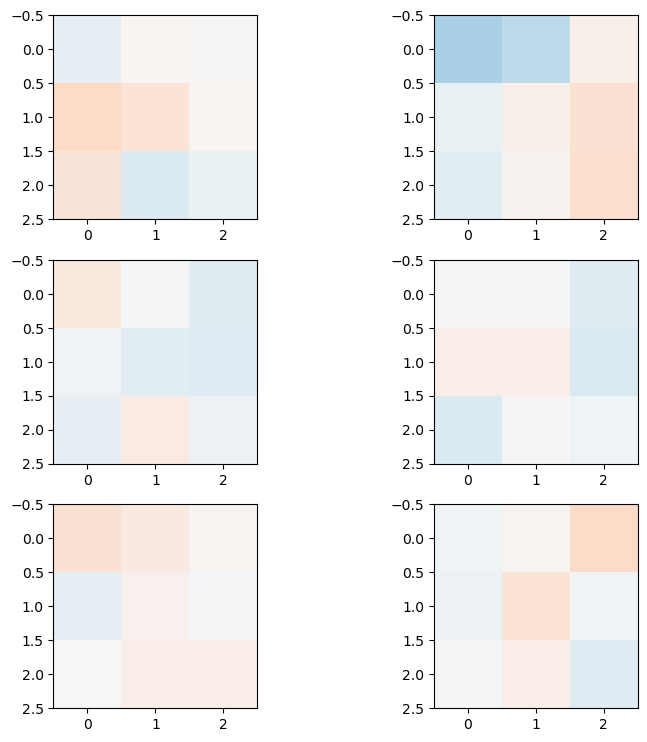

In [ ]:
params = list(net.parameters())
conv1 = params[-4].cpu().detach().numpy()
b1 = params[-3].cpu().detach().numpy()
print("kernel shape:", conv1.shape)
print("bias:", b1)

fig = plt.figure(figsize=(9, 9))  # Initiate figure with constrained layout
gs = fig.add_gridspec(3, 2)
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[1, 0])
ax3 = fig.add_subplot(gs[2, 0])
ax1.imshow(conv1[0, 0, :, :], cmap=cmap, vmin=-1, vmax=1)
ax2.imshow(conv1[0, 1, :, :], cmap=cmap, vmin=-1, vmax=1)
ax3.imshow(conv1[0, 2, :, :], cmap=cmap, vmin=-1, vmax=1)
ax12 = fig.add_subplot(gs[0, 1])
ax22 = fig.add_subplot(gs[1, 1])
ax32 = fig.add_subplot(gs[2, 1])
ax12.imshow(conv1[1, 0, :, :], cmap=cmap, vmin=-1, vmax=1)
ax22.imshow(conv1[1, 1, :, :], cmap=cmap, vmin=-1, vmax=1)
ax32.imshow(conv1[1, 2, :, :], cmap=cmap, vmin=-1, vmax=1)
plt.show()

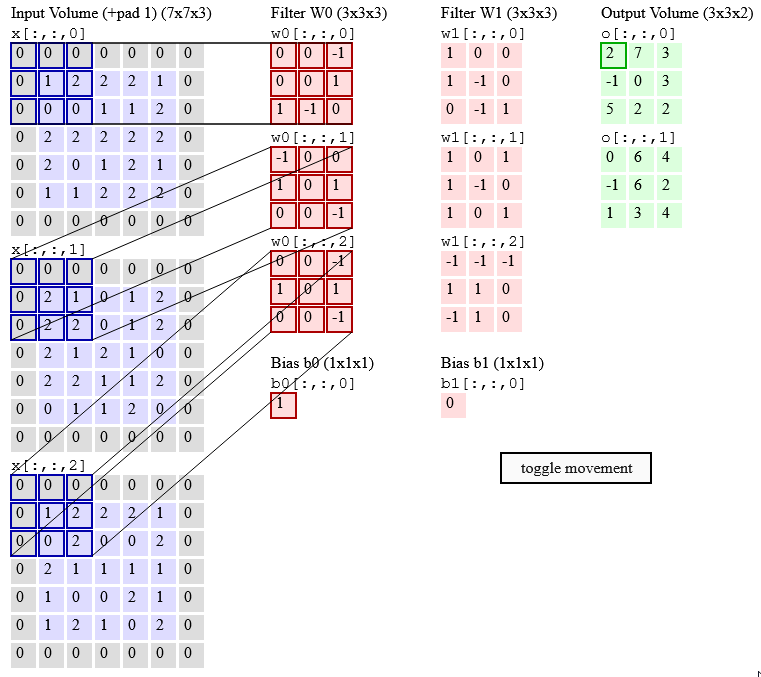

In [ ]:
Image(filename="conv_channels_visualized.gif")